In [2]:
import lyse
import h5py
import numpy as np
import matplotlib.pyplot as plt


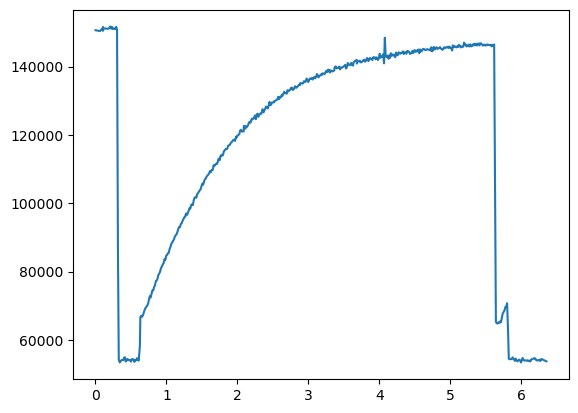

In [104]:
shot_file = r"D:\LiCs_Exp_Data\Experiments\lics_labscript_apparatus\cs_mot_healthcheck\2026\08\05\0000\2026-08-05_0000_cs_mot_healthcheck_0.h5"

with h5py.File(shot_file, 'r') as f:
    counts = f['images/ids_fluoro/fluorescence/counts'][:]
    timestamps = f['images/ids_fluoro/fluorescence/timestamps'][:]  # shape (N,), seconds from t=0




plt.plot(timestamps, counts)

Total frames: 1253
Duration: 15.6 s
Avg frame rate: 80.3 fps
Frames in MOT loading: 655


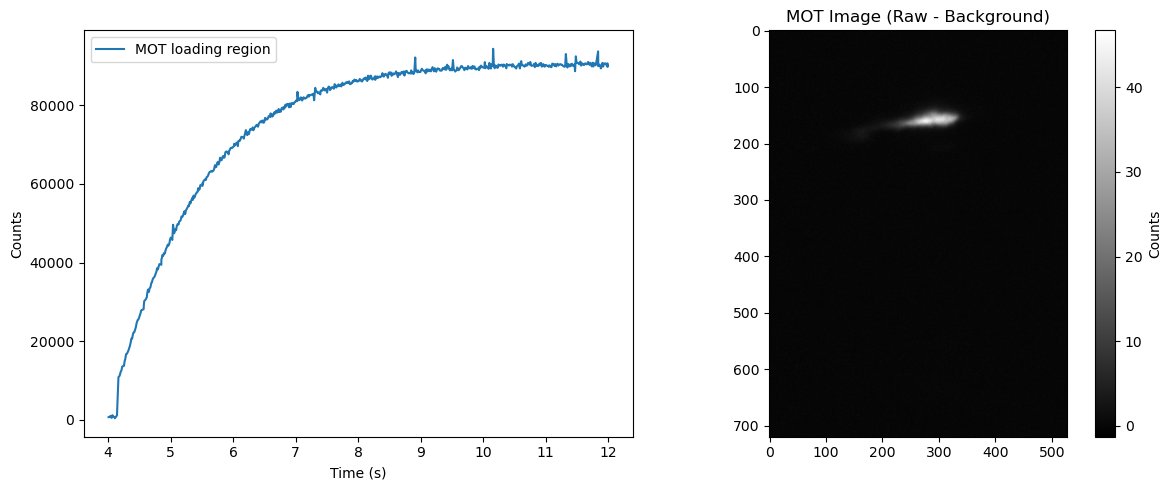

In [91]:
print(f"Total frames: {len(timestamps)}")
print(f"Duration: {timestamps[-1]:.1f} s")
print(f"Avg frame rate: {len(timestamps)/timestamps[-1]:.1f} fps")

# Slice the MOT loading region — adjust t_start/t_end based on your plot
t_start, t_end = 4, 12   # seconds from transition_to_buffered
mask = (timestamps >= t_start) & (timestamps <= t_end)
print(f"Frames in MOT loading: {mask.sum()}")

#slice the bacvkground region — adjust t_start/t_end based on your plot
bg_start, bg_end = 13, 14
bg_mask = (timestamps >= bg_start) & (timestamps <= bg_end)

#plot mot loading curve and mot image
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(timestamps[mask], counts[mask]-counts.min(), label='MOT loading region')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Counts')
axes[0].legend()

images_raw = images[mask][-1]
images_bg = images[bg_mask].mean(axis=0)  # average background image
images_mot = images_raw.astype(float) - images_bg.astype(float)

im1 = axes[1].imshow(images_mot, cmap='gray')
axes[1].set_title('MOT Image (Raw - Background)')
plt.colorbar(im1, ax=axes[1], label='Counts')

plt.tight_layout()
plt.show()

In [100]:
import os
run_name = os.path.basename(shot_file).split('_')
run_name = run_name[0] + "_" + run_name[1]
run_name

'2026-08-04_0000'

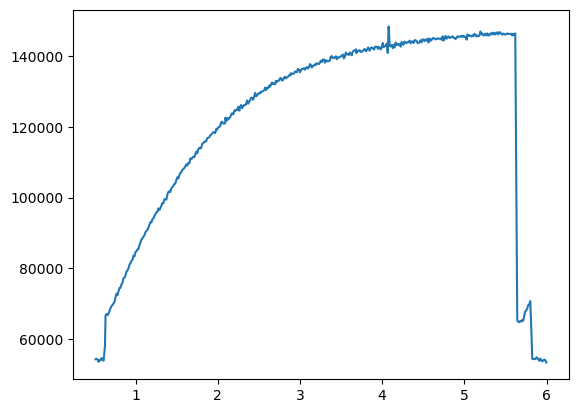

In [113]:
t_start, t_end = 0.5, 6  # seconds from transition_to_buffered
mask = (timestamps >= t_start) & (timestamps <= t_end)

plt.plot(timestamps[mask], counts[mask])